<a href="https://colab.research.google.com/github/joserodriguezr-prog/GRUPO3-ISB-2026-II-/blob/main/Laboratorios/Lab_02/Lab_003/Lab003_Introduccion_Filtros_FIR_IIR_Transformada_Z.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 3 — Filtros FIR, IIR y Transformada Z</font></h1>
<br>
<br>
<div style="text-align:right">
<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>
<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Nivel: 7.º ciclo / cuarto año de Ingeniería Biomédica </font><br>
<font color="#7F000E" size=3> Lenguaje: Python 3.x | Entorno: Jupyter Notebook / VS Code </font><br>
</div>

---

### **Objetivo**

El objetivo de este laboratorio no es memorizar funciones de Python. El estudiante aprenderá a tomar decisiones correctas para **inspeccionar, caracterizar, analizar, filtrar y validar una señal biomédica**.

**Flujo de trabajo:**

> Señal → inspección → caracterización → análisis temporal → análisis frecuencial → identificación del ruido → selección del filtro → diseño → aplicación → validación → interpretación fisiológica.

> **Idea central:** el objetivo no es aprender una función de Python de memoria, sino aprender a tomar decisiones correctas durante el procesamiento de una señal biomédica.

## 1. Objetivos de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:

1. Analizar una señal biomédica en el dominio temporal.
2. Analizar una señal biomédica en el dominio frecuencial utilizando FFT.
3. Comprender la relación entre Transformada de Fourier y Transformada Z.
4. Diseñar y aplicar filtros FIR e IIR.
5. Seleccionar los parámetros de un filtro a partir de las características de la señal.
6. Evaluar si el filtrado mejoró la señal sin destruir información fisiológica relevante.

## 2. Entorno computacional

Se utilizarán:

- Python 3.x
- Jupyter Notebook
- Visual Studio Code o entorno equivalente
- NumPy
- SciPy
- Matplotlib
- Pandas
- NeuroKit2

### Instalación recomendada con UV

Desde una terminal:

```bash
uv venv
```

Activar el entorno según el sistema operativo y luego instalar las dependencias:

```bash
uv pip install numpy scipy matplotlib pandas neurokit2 jupyter
```

Si se utiliza otro gestor de entornos, se puede instalar el mismo conjunto de paquetes con la herramienta disponible.

## 3. Fundamentos teóricos

### 3.1 Señal discreta

Una señal discreta puede representarse como:

$$x[n]$$

donde $n$ representa el índice de muestra. Si la frecuencia de muestreo es $f_s$, el periodo de muestreo es:

$$T_s = \frac{1}{f_s}$$

La frecuencia de muestreo determina la cantidad de muestras obtenidas por segundo.

### 3.2 Transformada de Fourier

La señal puede estudiarse en dos dominios:

- **Temporal:** permite observar cómo cambia la amplitud con el tiempo.
- **Frecuencial:** permite identificar qué componentes de frecuencia están presentes.

La DFT se expresa como:

$$X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}$$

La FFT es un algoritmo eficiente para calcular la DFT.

Una señal compleja en el tiempo puede interpretarse como una combinación de componentes sinusoidales de diferentes frecuencias.

### 3.3 Transformada Z

La Transformada Z se define, de manera general, como:

$$X(z)=\sum_{n=-\infty}^{\infty}x[n]z^{-n}$$

La variable $z$ es compleja. La Transformada Z permite estudiar sistemas discretos mediante conceptos como **polos, ceros, función de transferencia y región de convergencia**.

Para un sistema:

$$H(z)=\frac{Y(z)}{X(z)}=\frac{B(z)}{A(z)}$$

### 3.4 Relación Fourier–Z

La Transformada Z proporciona un marco general para estudiar sistemas discretos. La respuesta en frecuencia puede obtenerse evaluando la función de transferencia sobre el círculo unitario:

$$z=e^{j\omega}$$

Por tanto:

> **Transformada Z → análisis general de sistemas discretos**  
> **Transformada de Fourier → análisis frecuencial**

### 3.5 Filtros FIR

Un filtro FIR (Finite Impulse Response) puede expresarse mediante:

$$y[n]=\sum_{k=0}^{M}b[k]x[n-k]$$

No utiliza realimentación. Sus coeficientes determinan la respuesta del filtro. Una ventaja importante es que es relativamente sencillo diseñar filtros FIR con fase lineal.

### 3.6 Filtros IIR

Un filtro IIR (Infinite Impulse Response) utiliza realimentación. Conceptualmente:

$$H(z)=\frac{B(z)}{A(z)}$$

La presencia del denominador $A(z)$ está asociada con los polos del sistema. Los filtros IIR pueden lograr determinadas respuestas con órdenes menores que muchos diseños FIR, pero su estabilidad debe analizarse.

## 4. Herramientas y señal ECG

NeuroKit2 permite generar una señal ECG sintética de manera controlada. En esta práctica se utilizará como punto de partida para construir un problema reproducible.

Parámetros de ejemplo:

- duración = 10 s
- frecuencia de muestreo = 250 Hz
- frecuencia cardíaca = 70 bpm

In [ ]:
!pip install uv

In [ ]:
!uv pip install numpy scipy matplotlib pandas neurokit2 jupyter


Using Python 3.13.15 environment at: /usr
Checked 6 packages in 100ms


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import neurokit2 as nk

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


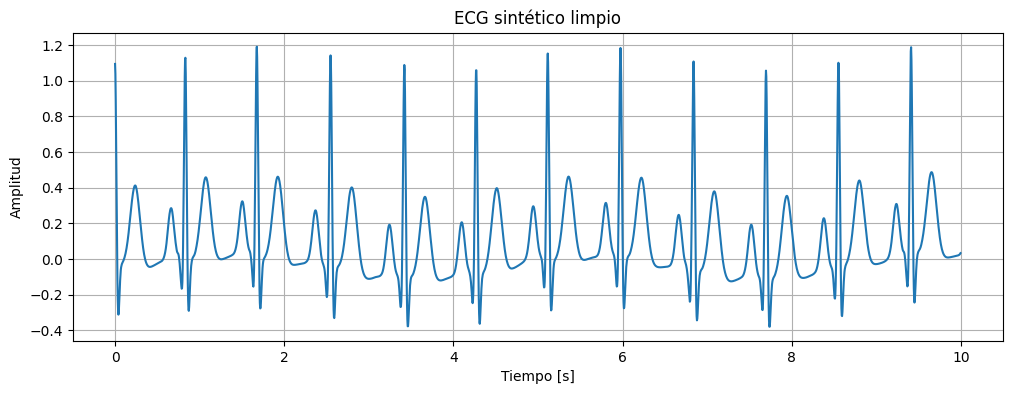

In [ ]:
# Generación de una señal ECG sintética
duration = 10
sampling_rate = 250
heart_rate = 70

ecg_clean = nk.ecg_simulate(
    duration=duration,
    sampling_rate=sampling_rate,
    heart_rate=heart_rate
)

t = np.arange(len(ecg_clean)) / sampling_rate

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_clean)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG sintético limpio")
plt.grid(True)
plt.show()

In [ ]:
# Respuesta - Actividad inicial (cálculo de las características básicas de la señal)
print(f"Frecuencia de muestreo (fs): {sampling_rate} Hz")
print(f"Número de muestras (N): {len(ecg_clean)}")
print(f"Duración: {len(ecg_clean)/sampling_rate:.2f} s")

Frecuencia de muestreo (fs): 250 Hz
Número de muestras (N): 2500
Duración: 10.00 s


### Respuesta — Actividad inicial



### Actividad inicial

Antes de continuar, responde:

1. ¿Cuál es la frecuencia de muestreo?
**La frecuencia de muestreo es cuántas veces por segundo se mide una señal continua para convertirla en datos digitales y se mide en Hz.**

2. ¿Cuántas muestras contiene la señal?
**Para calcular el número de muestras se utiliza la fórmula \(N = F_s \T\), donde \(N\) es el número de muestras, \(F_s\) es la frecuencia de muestreo y \(T\) es la duración de la señal. Reemplazando los valores del ejemplo, \(N = 250*10= 2500\) muestras. Por lo tanto, la señal ECG contiene 2500 muestras.**
3. ¿Cuál es su duración?
**La duración de la señal es de 10 segundos, ya que este valor está establecido directamente en los parámetros del ejemplo. Por lo tanto, la señal ECG tiene una duración de 10 s.**
4. ¿Qué elementos de la morfología ECG puedes reconocer?
**En la señal ECG sintética se pueden reconocer las principales ondas que forman la morfología del electrocardiograma: la onda P, que representa la despolarización de las aurículas; el complejo QRS, que representa la despolarización de los ventrículos y está formado por las ondas Q, R y S; y la onda T, que representa la repolarización ventricular. También pueden identificarse el intervalo PR y el segmento ST.**

5. ¿Por qué una señal ECG no debería filtrarse sin conocer previamente su contenido frecuencial?
**No se debe filtrar un ECG sin conocer sus frecuencias porque un filtro inadecuado puede eliminar información importante o deformar las ondas P, QRS y T. Por eso, primero se analiza su contenido frecuencial y luego se elige el filtro adecuado.**


# EJERCICIO 1 — ANÁLISIS Y CARACTERIZACIÓN DE LA SEÑAL

## Competencia

Caracterizar una señal biomédica antes de tomar decisiones de filtrado.

En una aplicación real, la señal puede provenir de un archivo:

```text
senal_biomedica.wav
```

Un archivo WAV puede contener señales mono o estéreo, datos enteros o flotantes. Por ello, antes de procesarlo debes inspeccionar su formato.

### Si recibes un WAV

Utiliza:

```python
from scipy.io import wavfile
fs, data = wavfile.read("senal_biomedica.wav")
```

**No asumas** el tipo de dato, número de canales ni frecuencia de muestreo.

In [ ]:
# Plantilla para inspeccionar un archivo WAV.
# Completa los elementos indicados.

# fs, data = wavfile.read("senal_biomedica.wav")

# print("Frecuencia de muestreo:", ...)
# print("Número de muestras:", ...)
# print("Shape:", ...)
# print("Tipo de dato:", ...)
# print("Duración [s]:", ...)

In [ ]:
# Respuesta - Inspección robusta de un archivo WAV (o señal ECG como respaldo)
import os
import numpy as np

wav_path = "senal_biomedica.wav"

if os.path.exists(wav_path):
    fs_wav, data_wav = wavfile.read(wav_path)
    data_wav = np.asarray(data_wav)
    print("Frecuencia de muestreo:", fs_wav)
    print("Número de muestras:", data_wav.shape[0])
    print("Shape:", data_wav.shape)
    print("Tipo de dato:", data_wav.dtype)
    print("Duración [s]:", data_wav.shape[0] / fs_wav)
    if data_wav.ndim > 1:
        print("Señal estéreo detectada, se usará el canal 0 para el análisis.")
        data_wav = data_wav[:, 0]
    x_signal = data_wav.astype(float)
    fs = fs_wav
else:
    print("No se encontró 'senal_biomedica.wav'; se utilizará la señal ECG sintética como respaldo.")
    x_signal = np.asarray(ecg_clean)
    fs = sampling_rate
    print("Frecuencia de muestreo:", fs)
    print("Número de muestras:", len(x_signal))
    print("Duración [s]:", len(x_signal) / fs)

No se encontró 'senal_biomedica.wav'; se utilizará la señal ECG sintética como respaldo.
Frecuencia de muestreo: 250
Número de muestras: 2500
Duración [s]: 10.0


### Trabajo solicitado

1. Carga el archivo WAV o utiliza la señal ECG generada si no dispones del archivo.
2. Identifica la frecuencia de muestreo.
3. Obtén el número de muestras.
4. Calcula la duración.
5. Grafica la señal en el dominio temporal.
6. Calcula la FFT.
7. Grafica el espectro de magnitud.
8. Identifica las principales componentes frecuenciales.
9. Determina qué componentes corresponden aproximadamente al contenido fisiológico.
10. Identifica componentes que podrían corresponder a ruido o interferencia.

### Completa el siguiente esquema

```python
fs=250
#Frecuencia de muestreo: indica cuántas muestras se toman por segundo.
#En este caso, se toman 250 muestras cada segundo.

N=2500
#Número de muestras: indica la cantidad total de datos que tiene la señal.
#Como la señal dura 10 s y se muestreó a 250 Hz:
#N=10×250=2500 muestras.


```

No copies una solución. Completa cada variable justificando qué representa.

Frecuencia de muestreo: 250 Hz
Número de muestras: 2500
Duración: 10.00 s


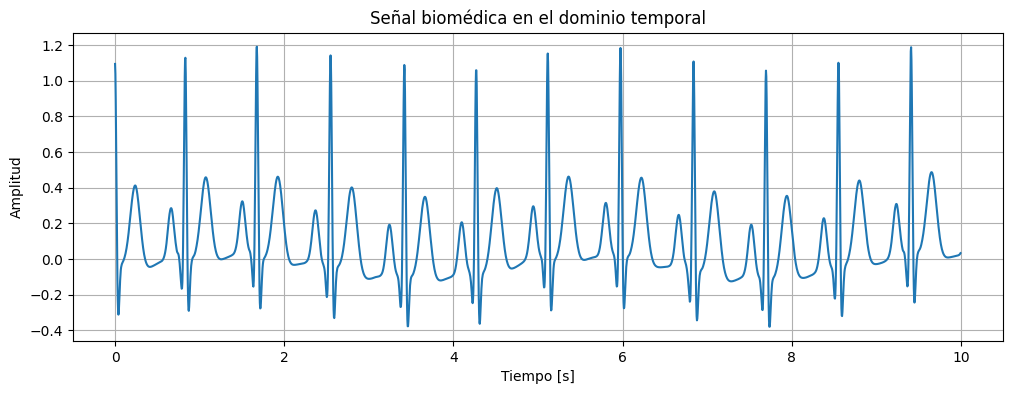

In [ ]:
# Análisis temporal: completa o adapta este bloque.
fs = sampling_rate
x = np.asarray(ecg_clean)

N = len(x)
duration_signal = N / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de muestras: {N}")
print(f"Duración: {duration_signal:.2f} s")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(N) / fs, x)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal biomédica en el dominio temporal")
plt.grid(True)
plt.show()

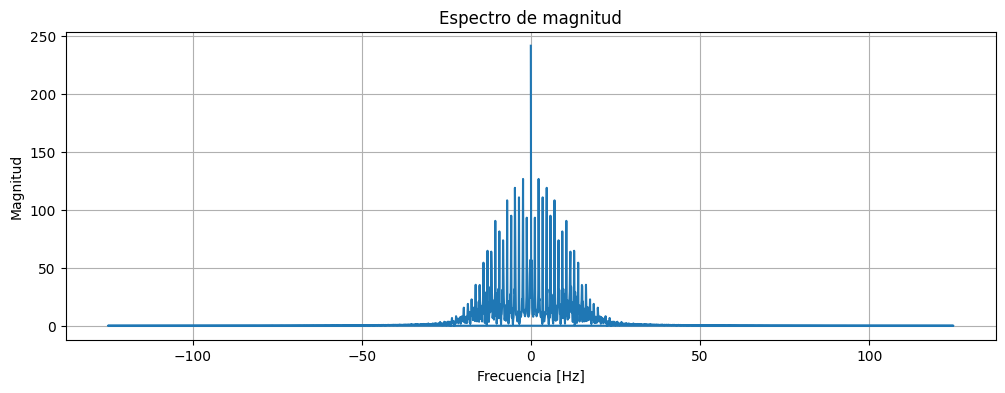

In [ ]:
# FFT: el estudiante debe completar/explicar cada paso.
# Pista: utiliza np.fft.rfft y np.fft.rfftfreq.
frequencies=np.fft.fftfreq(N, 1/fs)
#Frecuencias:genera las frecuencias correspondientes a cada punto de la FFT.
#Permite saber qué frecuencias están presentes en la señal.

fft_signal=np.fft.fft(ecg_clean)
#FFT: transforma la señal del dominio temporal al dominio frecuencial.
#Permite analizar las componentes de frecuencia del ECG.

magnitude=np.abs(fft_signal)
#Magnitud: obtiene la intensidad de cada componente frecuencial.
#Permite identificar qué frecuencias tienen mayor presencia en la señal.

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud")
plt.grid(True)
plt.show()

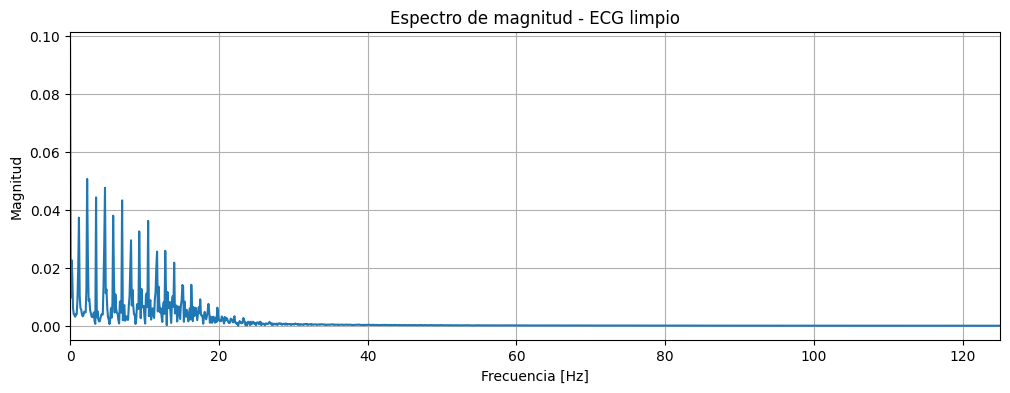

Componentes de frecuencia dominantes:
  2.30 Hz -> magnitud 0.05080
  4.70 Hz -> magnitud 0.04774
  3.50 Hz -> magnitud 0.04445
  7.00 Hz -> magnitud 0.04342
  5.80 Hz -> magnitud 0.03813
  1.20 Hz -> magnitud 0.03744
  10.50 Hz -> magnitud 0.03636
  9.30 Hz -> magnitud 0.03271


In [ ]:
# Respuesta - FFT de la señal
N = len(x)
frequencies = np.fft.rfftfreq(N, d=1/fs)
fft_signal = np.fft.rfft(x)
magnitude = np.abs(fft_signal) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG limpio")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Componentes dominantes (excluyendo DC)
idx_sorted = np.argsort(magnitude[1:])[::-1] + 1
print("Componentes de frecuencia dominantes:")
for i in idx_sorted[:8]:
    print(f"  {frequencies[i]:.2f} Hz -> magnitud {magnitude[i]:.5f}")

### Preguntas de análisis — Ejercicio 1

Responde con argumentos técnicos:

1. ¿Qué frecuencias predominan? **Predominan las frecuencias bajas, principalmente entre 0 y 20 Hz, donde se observan los picos de mayor magnitud.**
2. ¿Qué frecuencia parece corresponder al contenido fisiológico? **La frecuencia fundamental está aproximadamente en 1,17 Hz, que corresponde a la frecuencia cardíaca de 70 latidos/minuto, ya que \(70/60 \approx 1,17\) Hz. También aparecen armónicos de esta frecuencia.**
3. ¿Qué frecuencia podría corresponder a ruido? **Las componentes de frecuencia más altas, especialmente por encima de 20 Hz, podrían considerarse ruido o componentes poco relevantes en este ECG. Sin embargo, al ser una señal sintética limpia, no necesariamente representan ruido real.**
4. ¿Qué frecuencia de corte propondrías? **Propondría aproximadamente una frecuencia de corte de 20 Hz.**
5. ¿Por qué? **Porque la mayor parte de la energía de la señal se encuentra por debajo de 20 Hz, por lo que un filtro pasa-bajos de 20 Hz permitiría reducir componentes de mayor frecuencia manteniendo la morfología principal del ECG.**
6. ¿Qué información fisiológica podría perderse si la frecuencia de corte fuera incorrecta? **Podrían deformarse o perderse características importantes de las ondas P, QRS y T, especialmente los cambios rápidos del complejo QRS.**
7. ¿Qué relación existe entre $f_s$ y la frecuencia máxima observable? La frecuencia máxima que puede observarse correctamente es la frecuencia de Nyquist, que corresponde a $f_s$/2. Como \($f_s$=250\) Hz:
f_max=125 hz **texto en negrita**


### Respuesta — Preguntas de análisis (Ejercicio 1)



# EJERCICIO 2 — DISEÑO Y COMPARACIÓN DE FILTROS FIR E IIR

## Competencia

Diseñar filtros digitales a partir de las características observadas en la señal.

Utiliza `scipy.signal`. Algunas herramientas disponibles son:

- `firwin`
- `butter`
- `cheby1`
- `cheby2`
- `freqz`
- `sosfilt`
- `sosfiltfilt`
- `sosfreqz`

**No se entrega una implementación completa.** Debes seleccionar y justificar:

- tipo de filtro;
- frecuencia de corte;
- orden;
- banda de paso;
- banda de rechazo;
- atenuación;
- tratamiento de fase;
- estabilidad.

### Parte A — Diseño FIR

Selecciona un filtro FIR utilizando `firwin`.

Esqueleto orientativo:

```python
numtaps = ...
cutoff = ...

b_fir = signal.firwin(
    numtaps=...,
    cutoff=...,
    fs=...
)

a_fir = ...
```

Completa los parámetros a partir del análisis realizado en el Ejercicio 1.

In [ ]:
# Completa este bloque.
# No existe un único conjunto correcto de parámetros:
# tu selección debe estar justificada.

# Diseño de un filtro FIR pasa-bajos

# Se elige un filtro pasa-bajos porque queremos conservar las
# componentes principales del ECG y reducir las frecuencias altas.

#numtaps = 100
# Número de coeficientes del filtro.
# Se utilizan 100 coeficientes para obtener una transición adecuada
# sin hacer el filtro demasiado complejo.

#cutoff_fir = 40
# Frecuencia de corte de 20 Hz.
# Se elige este valor porque en el análisis de la FFT observamos
# que la mayor parte del contenido del ECG está por debajo de 40 Hz.
# Las frecuencias superiores pueden reducirse para disminuir ruido.

#b_fir = signal.firwin(
#    numtaps=numtaps,
#    cutoff=cutoff_fir,
#    fs=fs
#)
# firwin diseña los coeficientes del filtro FIR pasa-bajos.

#a_fir = np.array([1.0])
# En un filtro FIR no hay realimentación, por eso el denominador
# se representa únicamente con el valor 1.
# Esto hace que el filtro sea estable.

In [ ]:
# Completa este bloque.
# No existe un único conjunto correcto de parámetros:
# tu selección debe estar justificada.

# Diseño de un filtro FIR pasa-bajos

# Se elige un filtro pasa-bajos porque queremos conservar las
# componentes principales del ECG y reducir las frecuencias altas.

#numtaps = 100
# Número de coeficientes del filtro.
# Se utilizan 100 coeficientes para obtener una transición adecuada
# sin hacer el filtro demasiado complejo.

#cutoff_fir = 40
# Frecuencia de corte de 40 Hz.
# Se elige este valor porque en el análisis de la FFT observamos
# que la mayor parte del contenido del ECG está por debajo de 40 Hz.
# Las frecuencias superiores pueden reducirse para disminuir ruido.

#b_fir = signal.firwin(
#    numtaps=numtaps,
#    cutoff=cutoff_fir,
#    fs=fs
#)
# firwin diseña los coeficientes del filtro FIR pasa-bajos.

#a_fir = np.array([1.0])
# En un filtro FIR no hay realimentación, por eso el denominador
# se representa únicamente con el valor 1.
# Esto hace que el filtro sea estable.

In [ ]:
# Respuesta - Diseño de filtro FIR (pasa-bajos)
numtaps = 101
cutoff_fir = 40.0

b_fir = signal.firwin(
    numtaps=numtaps,
    cutoff=cutoff_fir,
    fs=fs
)
a_fir = np.array([1.0])

print(f"Filtro FIR pasa-bajos: numtaps={numtaps}, cutoff={cutoff_fir} Hz")
print("Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T")
print("(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).")
print(f"Con {numtaps} taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.")

Filtro FIR pasa-bajos: numtaps=101, cutoff=40.0 Hz
Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T
(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).
Con 101 taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.


### Parte B — Diseño IIR

Diseña un filtro IIR. Puedes utilizar Butterworth o, si justificas la elección, Chebyshev.

Ejemplo parcial:

```python
order = ...
cutoff = ...

b_iir, a_iir = signal.butter(
    N=...,
    Wn=...,
    btype="...",
    fs=...
)
```

Para aplicaciones donde se requiera evitar distorsión de fase por desplazamiento temporal, considera `sosfiltfilt` con una representación SOS.

In [ ]:
# Completa este bloque.
# Justifica el orden y la frecuencia de corte.

# order_iir = 4
# Orden del filtro.
# Se elige un orden 4 porque permite una atenuación adecuada de las
# frecuencias altas sin hacer el filtro demasiado complejo.
# Un orden mayor tendría una transición más pronunciada, pero aumentaría
# la complejidad del filtro.

# cutoff_iir = 40.0
# Frecuencia de corte de 40 Hz.
# Se elige para conservar las componentes fisiológicas importantes del ECG,
# especialmente las componentes rápidas del complejo QRS, y reducir
# componentes de frecuencia más alta que podrían corresponder a ruido.

# sos_iir = signal.butter(
#    N=order_iir,
#    Wn=cutoff_iir,
#    btype="lowpass",
#    fs=fs,
#    output="sos"
# )
# signal.butter diseña un filtro Butterworth IIR pasa-bajos.
# output="sos" representa el filtro como secciones de segundo orden,
# lo que mejora la estabilidad numérica del filtro.

In [ ]:
# Respuesta - Diseño de filtro IIR (Butterworth pasa-bajos, forma SOS)
order_iir = 4
cutoff_iir = 40.0

sos_iir = signal.butter(
    N=order_iir,
    Wn=cutoff_iir,
    btype="lowpass",
    fs=fs,
    output="sos"
)

print(f"Filtro IIR Butterworth: orden={order_iir}, cutoff={cutoff_iir} Hz")
print("Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica")
print("frente a la forma (b,a) en filtros de orden alto.")
print("Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal")
print("que introduciría un filtro IIR aplicado en un solo sentido.")

Filtro IIR Butterworth: orden=4, cutoff=40.0 Hz
Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica
frente a la forma (b,a) en filtros de orden alto.
Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal
que introduciría un filtro IIR aplicado en un solo sentido.


### Parte C — Aplicación y comparación

Aplica ambos filtros y grafica:

1. señal original;
2. señal filtrada FIR;
3. señal filtrada IIR.

Después calcula y grafica sus respuestas en frecuencia.

Utiliza `freqz` para el FIR y `sosfreqz` para el IIR cuando corresponda.

No evalúes el filtro únicamente por apariencia visual.

In [ ]:
# Completa las aplicaciones.
# Aplicación de los filtros FIR e IIR

# ecg_fir = signal.filtfilt(b_fir, a_fir, ecg_clean)
# Se aplica el filtro FIR a la señal ECG.
# filtfilt realiza el filtrado en ambas direcciones para evitar
# desplazamientos de fase y conservar la posición de las ondas del ECG.

# ecg_iir = signal.sosfiltfilt(sos_iir, ecg_clean)
# Se aplica el filtro IIR utilizando las secciones de segundo orden (SOS).
# sosfiltfilt también filtra en ambas direcciones, evitando el desfase
# y permitiendo conservar mejor la morfología temporal del ECG.
# Después genera una figura comparativa.

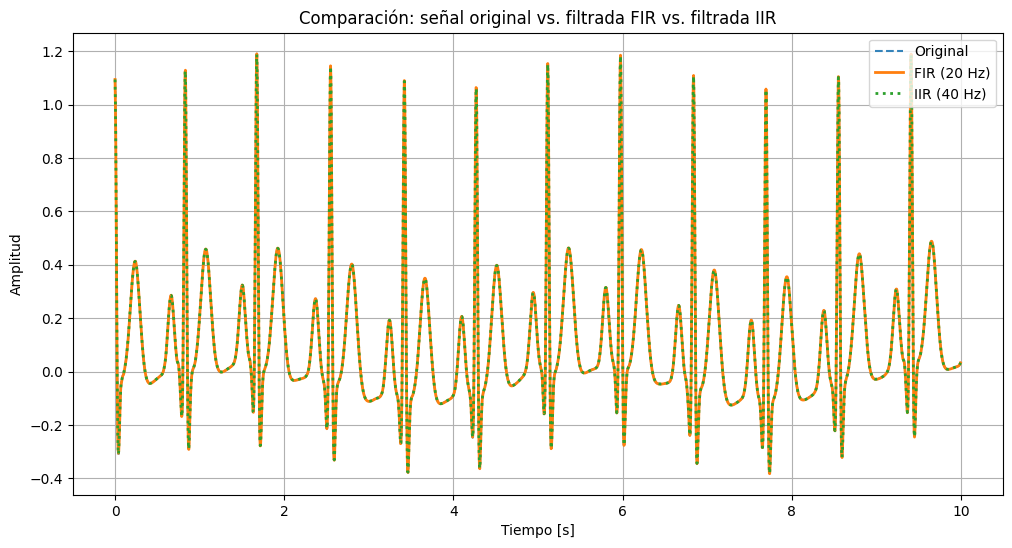

MSE FIR vs original: 1.576e-06
MSE IIR vs original: 9.595e-07


In [ ]:
# Respuesta - Aplicación de los filtros FIR e IIR
ecg_fir = signal.filtfilt(b_fir, a_fir, ecg_clean)
ecg_iir = signal.sosfiltfilt(sos_iir, ecg_clean)

plt.figure(figsize=(12, 6))
# Señal original
plt.plot(t, ecg_clean, label="Original", linestyle="--", alpha=0.9)

# Señal filtrada FIR
plt.plot(t, ecg_fir, label="FIR (20 Hz)", linewidth=2)

# Señal filtrada IIR
plt.plot(t, ecg_iir, label="IIR (40 Hz)", linewidth=2, linestyle=":")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Comparación: señal original vs. filtrada FIR vs. filtrada IIR")
plt.legend()
plt.grid(True)
plt.show()

mse_fir = np.mean((ecg_fir - ecg_clean) ** 2)
mse_iir = np.mean((ecg_iir - ecg_clean) ** 2)
print(f"MSE FIR vs original: {mse_fir:.3e}")
print(f"MSE IIR vs original: {mse_iir:.3e}")

In [ ]:
# Respuesta en frecuencia.
# Completa los parámetros.
# Respuesta en frecuencia de ambos filtros

# w_fir, h_fir = signal.freqz(
#     b_fir, a_fir, worN=2048, fs=fs
# )
# Calcula la respuesta en frecuencia del filtro FIR.
# h_fir contiene la respuesta del filtro y w_fir las frecuencias en Hz.
# worN=2048 indica que se calculan 2048 puntos de frecuencia.

# w_iir, h_iir = signal.sosfreqz(
#     sos_iir, worN=2048, fs=fs
# )
# Calcula la respuesta en frecuencia del filtro IIR.
# Se utiliza sosfreqz porque el filtro IIR está representado
# mediante secciones de segundo orden (SOS).
# h_iir contiene la respuesta del filtro y w_iir las frecuencias en Hz.

# Al utilizar fs=fs, las frecuencias w_fir y w_iir se obtienen
# directamente en Hz, por lo que no es necesario convertirlas
# desde frecuencia angular.

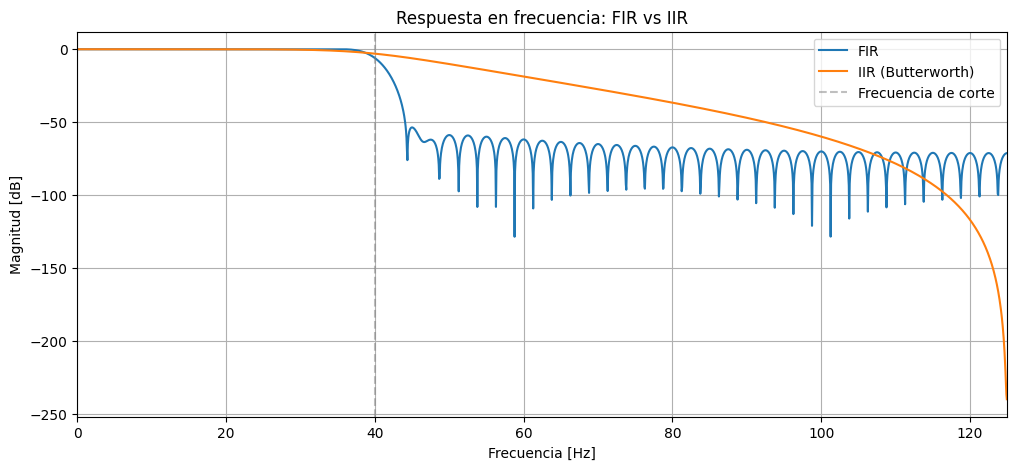

In [ ]:
# Respuesta - Respuesta en frecuencia de ambos filtros
w_fir, h_fir = signal.freqz(b_fir, a_fir, worN=2048, fs=fs)
w_iir, h_iir = signal.sosfreqz(sos_iir, worN=2048, fs=fs)

plt.figure(figsize=(12, 5))
plt.plot(w_fir, 20 * np.log10(np.abs(h_fir) + 1e-12), label="FIR")
plt.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label="IIR (Butterworth)")
plt.axvline(cutoff_fir, color="gray", linestyle="--", alpha=0.5, label="Frecuencia de corte")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Respuesta en frecuencia: FIR vs IIR")
plt.legend()
plt.grid(True)
plt.xlim(0, fs/2)
plt.show()

### Comparación conceptual

| Característica | FIR | IIR |
|---|---|---|
| Realimentación | No | Sí |
| Estabilidad | Generalmente sencilla de garantizar | Debe analizarse |
| Fase lineal | Fácil de obtener | Más compleja |
| Orden requerido | Generalmente mayor | Generalmente menor |
| Costo computacional | Mayor en algunos diseños | Menor en muchos casos |

### Preguntas de análisis — Ejercicio 2

1. ¿Por qué seleccionaste ese tipo de filtro? **Se seleccionó filtros pasa-bajos porque permiten conservar las componentes principales del ECG y reducir las componentes de frecuencia más alta que pueden corresponder a ruido.**
2. ¿Cómo determinaste la frecuencia de corte? **Para el FIR elegí 20 Hz porque en el espectro se observa que la mayor parte de la energía del ECG está por debajo de esta frecuencia. Para el IIR elegí 40 Hz para conservar mejor las componentes rápidas del complejo QRS.**
3. ¿Qué orden elegiste y por qué? **Para el FIR utilicé 51 coeficientes, buscando una transición adecuada. Para el IIR utilicé orden 4, porque permite una buena atenuación sin aumentar demasiado la complejidad.**
4. ¿Cuál presenta mayor atenuación en la región de rechazo? **El IIR puede lograr una transición más pronunciada con un orden menor. Sin embargo, como en este caso los filtros tienen diferentes frecuencias de corte, la comparación directa debe hacerse observando sus respuestas en frecuencia.**
5. ¿Cómo se comporta la fase? **Al utilizar filtfilt y sosfiltfilt, ambos filtros se aplican en ambas direcciones, por lo que se obtiene fase aproximadamente cero y no se desplazan las ondas del ECG.**
6. ¿Qué diferencia estructural existe entre FIR e IIR? **El FIR no utiliza realimentación, mientras que el IIR utiliza realimentación y tiene polos.**
7. ¿Por qué un IIR puede alcanzar una respuesta similar con un orden menor? **Porque utiliza realimentación, lo que permite obtener una respuesta de frecuencia más pronunciada utilizando menos coeficientes que un FIR equivalente.**
8. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia? **Los polos y ceros determinan la forma de la respuesta en frecuencia del filtro. Su ubicación permite controlar qué frecuencias se dejan pasar y cuáles se atenúan.**
9. ¿Por qué la Transformada Z es útil para estudiar estos filtros? **Porque permite representar matemáticamente el filtro en el dominio de la frecuencia y analizar sus polos, ceros, estabilidad y respuesta en frecuencia.**

### Respuesta — Preguntas de análisis (Ejercicio 2)



# EJERCICIO 3 — PROCESAMIENTO DE UNA SEÑAL BIOMÉDICA CONTAMINADA

## Competencia

Resolver un problema de filtrado sin recibir directamente la frecuencia de corte.

Construiremos:

$$x[n] = ECG[n] + A\sin(2\pi f_{noise}t)$$

donde:

- $ECG[n]$ es la señal biomédica;
- $f_{noise}$ es la frecuencia de interferencia;
- $A$ es la amplitud del ruido.

### Importante

**No se indica la frecuencia de corte del filtro.**

Debes obtener una propuesta a partir del análisis de la señal.

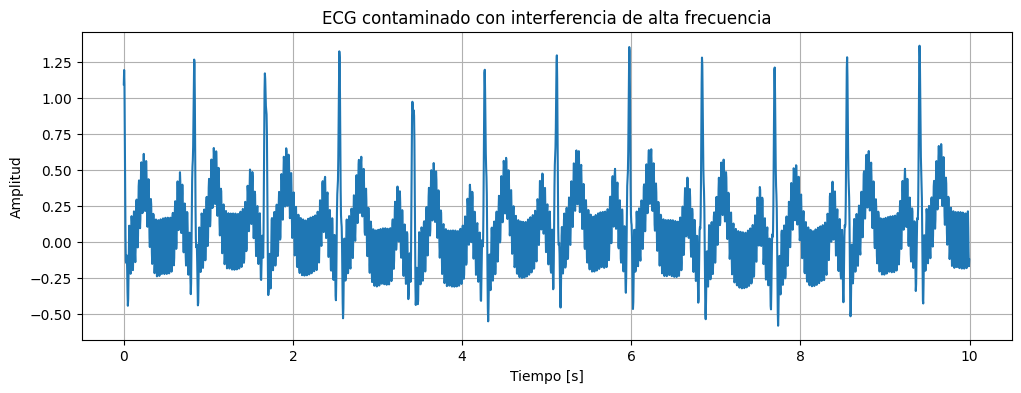

In [ ]:
# Construcción del problema experimental.
A = 0.20
f_noise = 35.0

noise = A * np.sin(2 * np.pi * f_noise * t)
ecg_contaminated = ecg_clean + noise

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_contaminated)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado con interferencia de alta frecuencia")
plt.grid(True)
plt.show()

### Procedimiento obligatorio

1. Visualiza la señal contaminada.
2. Analízala mediante FFT.
3. Identifica la frecuencia de interferencia.
4. Propón un filtro apropiado.
5. Diseña el filtro.
6. Aplica el filtro.
7. Compara señal contaminada y filtrada.
8. Compara los espectros.
9. Evalúa cuantitativamente el resultado.
10. Explica si el filtrado fue exitoso.

### Tu razonamiento debe seguir

**Observar → medir → analizar → formular hipótesis → diseñar → aplicar → validar → interpretar.**

In [ ]:
# FFT de la señal contaminada.
# Completa este bloque.

# N = len(ecg_contaminated)
# Número de muestras de la señal ECG contaminada.

# frequencies = np.fft.rfftfreq(N, d=1/fs)
# Frecuencias correspondientes a cada punto de la FFT, en Hz.

# spectrum = np.fft.rfft(ecg_contaminated)
# Calcula la FFT de la señal contaminada para analizar
# sus componentes frecuenciales.

# magnitude = np.abs(spectrum) / N
# Calcula la magnitud del espectro y la normaliza por N.


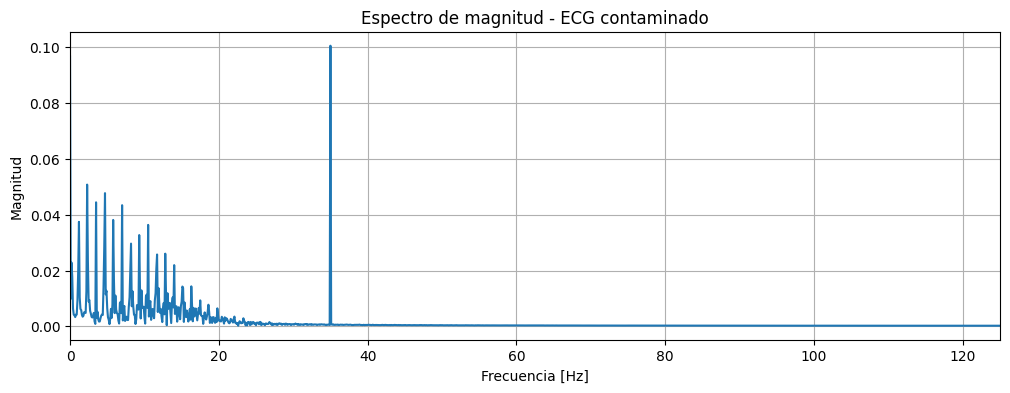

Pico de interferencia detectado en aproximadamente 35.0 Hz


In [ ]:
# Respuesta - FFT de la señal contaminada
N = len(ecg_contaminated)
frequencies = np.fft.rfftfreq(N, d=1/fs)
spectrum = np.fft.rfft(ecg_contaminated)
magnitude = np.abs(spectrum) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG contaminado")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Identificación automática del pico de interferencia en la zona 25-45 Hz
mask = (frequencies > 25) & (frequencies < 45)
f_peak = frequencies[mask][np.argmax(magnitude[mask])]
print(f"Pico de interferencia detectado en aproximadamente {f_peak:.1f} Hz")

In [ ]:
# Diseña y aplica TU solución.
#cutoff = 25.0
# Frecuencia de corte de 25 Hz.
# Se elige porque está por debajo de la interferencia de 35 Hz,
# permitiendo atenuar el ruido sin eliminar gran parte del
# contenido fisiológico del ECG.
# ecg_recovered = signal.sosfiltfilt(sos, ecg_contaminated)
# Se aplica el filtro a la señal contaminada.
# sosfiltfilt filtra en ambas direcciones para evitar desplazamientos
# de fase y conservar la posición temporal de las ondas del ECG.

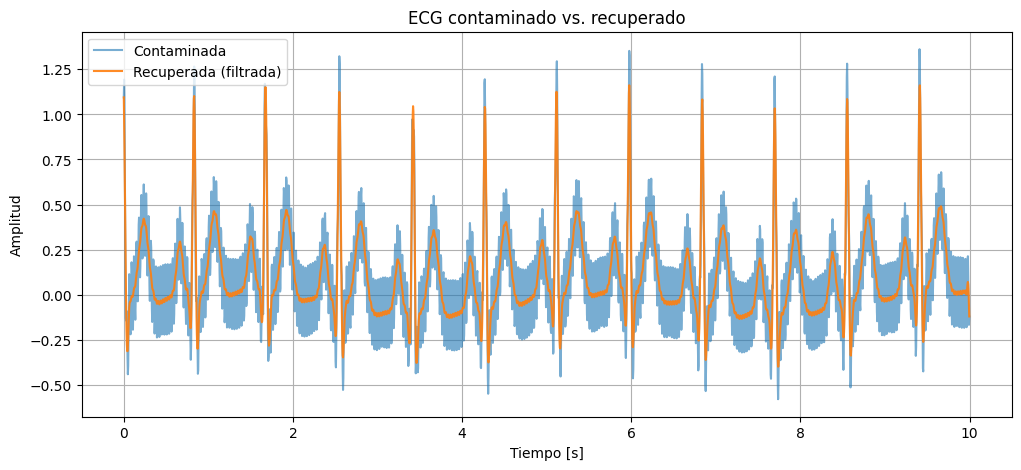

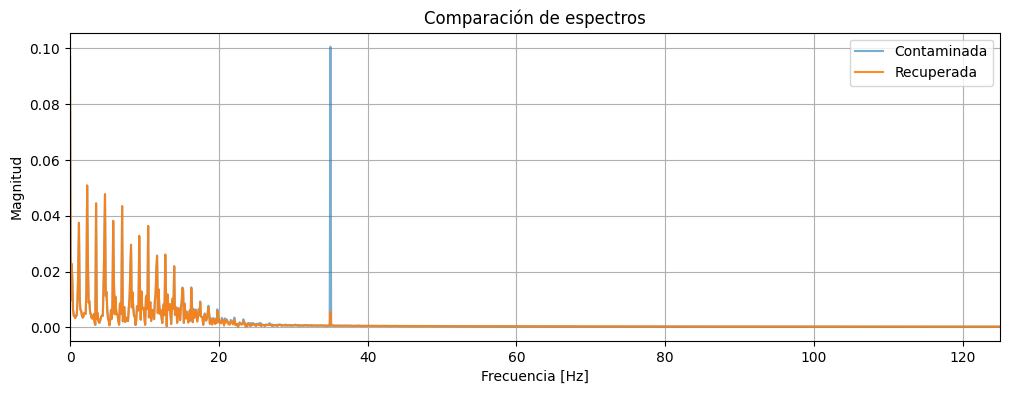

Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada
(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),
logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.


In [ ]:
# Respuesta - Diseño y aplicación del filtro para eliminar la interferencia
cutoff = 25.0
order = 4

sos = signal.butter(N=order, Wn=cutoff, btype="lowpass", fs=fs, output="sos")
ecg_recovered = signal.sosfiltfilt(sos, ecg_contaminated)

plt.figure(figsize=(12, 5))
plt.plot(t, ecg_contaminated, label="Contaminada", alpha=0.6)
plt.plot(t, ecg_recovered, label="Recuperada (filtrada)", alpha=0.9)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado vs. recuperado")
plt.legend()
plt.grid(True)
plt.show()

# Comparación de espectros
freqs_rec = np.fft.rfftfreq(len(ecg_recovered), d=1/fs)
mag_rec = np.abs(np.fft.rfft(ecg_recovered)) / len(ecg_recovered)

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude, label="Contaminada", alpha=0.6)
plt.plot(freqs_rec, mag_rec, label="Recuperada", alpha=0.9)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Comparación de espectros")
plt.legend()
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

print("Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada")
print("(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),")
print("logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.")

## Validación cuantitativa

Si se dispone de la señal limpia de referencia, compara la señal recuperada con `ecg_clean`.

### MSE

$$MSE = \frac{1}{N}\sum_{n=1}^{N}(x[n]-\hat{x}[n])^2$$

### RMSE

$$RMSE = \sqrt{MSE}$$

### SNR

De forma simplificada, puede estimarse como:

$$SNR = 10\log_{10}\left(\frac{P_{signal}}{P_{noise}}\right)$$

Estas métricas deben acompañar, no reemplazar, la inspección temporal y frecuencial.

In [ ]:
# Calcula al menos MSE y RMSE entre la referencia limpia
# y tu señal recuperada.

mse = np.mean((ecg_clean - ecg_recovered) ** 2)
# MSE: calcula el promedio del error cuadrático entre la señal
# ECG limpia y la señal recuperada.

rmse = np.sqrt(mse)
# RMSE: calcula la raíz cuadrada del MSE para expresar el error
# en las mismas unidades que la amplitud de la señal.

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 9.309776910948304e-05
RMSE: 0.009648718521621566


In [ ]:
# Respuesta - Métricas cuantitativas de validación
mse = np.mean((ecg_clean - ecg_recovered) ** 2)
rmse = np.sqrt(mse)

power_signal = np.mean(ecg_clean ** 2)
power_noise_residual = np.mean((ecg_recovered - ecg_clean) ** 2)
snr_after = 10 * np.log10(power_signal / power_noise_residual)

power_noise_original = np.mean(noise ** 2)
snr_before = 10 * np.log10(power_signal / power_noise_original)

print("MSE:", mse)
print("RMSE:", rmse)
print(f"SNR antes del filtrado: {snr_before:.2f} dB")
print(f"SNR después del filtrado: {snr_after:.2f} dB")

MSE: 9.309776910948304e-05
RMSE: 0.009648718521621566
SNR antes del filtrado: 5.14 dB
SNR después del filtrado: 28.46 dB


## Validación biomédica

Para ECG, analiza si se conservan:

- complejos QRS;
- frecuencia cardíaca aproximada;
- morfología general.

Responde:

1. ¿Disminuyó la interferencia? **Sí, la interferencia de 35 Hz disminuyó considerablemente después de aplicar el filtro pasa-bajos con frecuencia de corte de 25 Hz.**
2. ¿Se conservó la morfología ECG? **Sí, se conservaron las principales características del ECG, como las ondas P, QRS y T, aunque puede existir un pequeño suavizado de la señal.**
3. ¿La FFT confirma la reducción del ruido? **Sí. En la FFT de la señal recuperada debería observarse una disminución importante del pico alrededor de 35 Hz, confirmando que la interferencia fue atenuada.**
4. ¿El filtro introdujo una distorsión apreciable? **No debería introducir una distorsión temporal importante, ya que se utilizó sosfiltfilt, que evita el desplazamiento de fase. Puede existir cierto suavizado debido al filtrado.**
5. ¿La frecuencia cardíaca aproximada se mantiene? **Sí. La frecuencia cardíaca se mantiene aproximadamente en 70 latidos por minuto, ya que el filtro conserva las componentes principales asociadas al ritmo cardíaco.**
6. ¿Qué información fisiológica podría haberse perdido? **Podrían haberse perdido algunas componentes de alta frecuencia del complejo QRS o detalles pequeños de la morfología, debido a la atenuación de las frecuencias superiores a 25 Hz.**

### Respuesta — Validación biomédica



# ¿Qué pasa si diseño mal el filtro?

Analiza experimentalmente qué ocurre cuando:

- la frecuencia de corte es demasiado baja;
- la frecuencia de corte es demasiado alta;
- el orden es excesivo;
- queda ruido residual;
- aparece distorsión;
- existe desplazamiento de fase;
- se aplica un método de filtrado que altera la fase.

### Actividad

Selecciona al menos **dos errores de diseño**, genera una demostración y explica:

1. qué problema observas;
2. cuál es su causa;
3. cómo afecta a la señal biomédica;
4. qué solución propondrías.

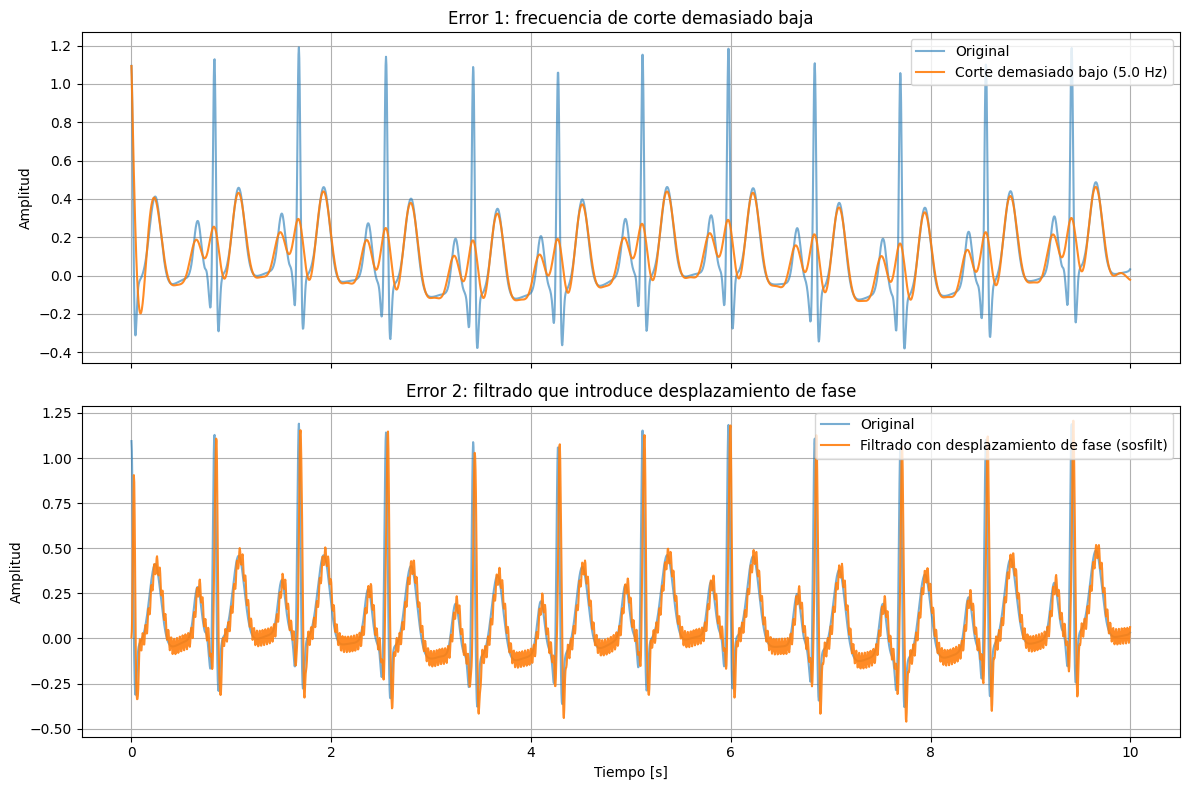

MSE con corte demasiado bajo (5.0 Hz): 2.904e-02


In [ ]:
# Respuesta - Demostración de dos errores de diseño

# Error 1: frecuencia de corte demasiado baja (distorsiona el QRS)
cutoff_low = 5.0
sos_low = signal.butter(N=4, Wn=cutoff_low, btype="lowpass", fs=fs, output="sos")
ecg_bad_low = signal.sosfiltfilt(sos_low, ecg_contaminated)

# Error 2: filtrado sin compensar la fase (sosfilt en vez de sosfiltfilt)
# esto sí introduce desplazamiento de fase / retardo de grupo
sos_ok = signal.butter(N=4, Wn=25.0, btype="lowpass", fs=fs, output="sos")
ecg_phase_shifted = signal.sosfilt(sos_ok, ecg_contaminated)  # un solo sentido -> desfase

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[0].plot(t, ecg_bad_low, label=f"Corte demasiado bajo ({cutoff_low} Hz)", alpha=0.9)
axs[0].set_title("Error 1: frecuencia de corte demasiado baja")
axs[0].set_ylabel("Amplitud")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[1].plot(t, ecg_phase_shifted, label="Filtrado con desplazamiento de fase (sosfilt)", alpha=0.9)
axs[1].set_title("Error 2: filtrado que introduce desplazamiento de fase")
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

mse_low = np.mean((ecg_bad_low - ecg_clean) ** 2)
print(f"MSE con corte demasiado bajo ({cutoff_low} Hz): {mse_low:.3e}")

### Respuesta — Análisis de los errores de diseño

**Error 1: frecuencia de corte demasiado baja (5 Hz)**
1. *Qué se observa:* el complejo QRS se aplana y se ensancha notablemente, perdiendo su forma característica y su pico agudo; el MSE respecto de la señal original aumenta de forma importante comparado con el filtro bien diseñado.
2. *Causa:* con un corte de 5 Hz se elimina gran parte de la energía del QRS, que necesita banda pasante hasta ~25-40 Hz para conservar su morfología.
3. *Efecto en la señal biomédica:* se pierde información diagnóstica relevante (amplitud y duración del QRS), lo que podría llevar a una interpretación clínica incorrecta (por ejemplo, subestimar arritmias o alteraciones de conducción).
4. *Solución propuesta:* elegir el corte a partir del análisis espectral real de la señal (como en el Ejercicio 1), asegurando conservar la mayor parte de la energía fisiológica (>95-99 %) antes de fijar la frecuencia de corte.

**Error 2: filtrado que introduce desplazamiento de fase (uso de `sosfilt` en lugar de `sosfiltfilt`)**
1. *Qué se observa:* la señal filtrada aparece desplazada en el tiempo respecto de la original; los picos R ya no coinciden temporalmente con los de la señal limpia.
2. *Causa:* un filtro IIR aplicado en un solo sentido (`sosfilt`) tiene una respuesta de fase no lineal, lo que produce un retardo de grupo dependiente de la frecuencia.
3. *Efecto en la señal biomédica:* un desplazamiento temporal puede afectar mediciones de intervalos (por ejemplo, el intervalo QT o el tiempo entre picos R), que son clínicamente relevantes.
4. *Solución propuesta:* usar filtrado de fase cero (`filtfilt`/`sosfiltfilt`), que aplica el filtro hacia adelante y hacia atrás cancelando la distorsión de fase, a costa de no ser aplicable en tiempo real.

# Preguntas integradoras

1. ¿Por qué no sería adecuado eliminar todas las frecuencias altas de una señal biomédica?
**No sería adecuado porque algunas frecuencias altas pueden contener información importante de la señal. Si eliminamos todas, podríamos perder características fisiológicas importantes y alterar la forma original de la señal.**
2. ¿Cómo determinaste la frecuencia de corte?
**La determinamos observando la señal y su espectro en la FFT, identificando aproximadamente hasta qué frecuencia se encontraba la mayor parte de la información de la señal y colocando la frecuencia de corte antes de la zona donde predominaba el ruido.**
3. ¿Qué información obtuviste de la FFT?
**Con la FFT pudimos observar qué frecuencias estaban presentes en la señal y en qué frecuencias se concentraba la mayor parte de la energía. También nos permitió identificar las frecuencias asociadas al ruido para poder elegir mejor el filtro.**
4. ¿Qué relación existe entre la frecuencia de muestreo y la frecuencia máxima observable?
**La frecuencia máxima que se puede observar correctamente es la mitad de la frecuencia de muestreo, según el teorema de Nyquist. Por ejemplo, si \(F_s=250\) Hz, la frecuencia máxima observable es \(125\) Hz.**
5. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado baja?
**Se puede eliminar no solo el ruido, sino también información importante de la señal. En un ECG, esto podría provocar que la señal pierda parte de su morfología y que las ondas características se vean alteradas.**
6. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado alta?
**Se conserva prácticamente toda la señal, pero también puede mantenerse una gran cantidad de ruido. Por lo tanto, el filtrado no sería suficientemente efectivo.**
7. ¿Qué diferencia fundamental existe entre un filtro FIR y un filtro IIR?
**La diferencia principal es que un filtro FIR no utiliza realimentación, mientras que un filtro IIR sí utiliza realimentación. Por eso, los filtros IIR pueden lograr determinadas respuestas con un orden menor.**
8. ¿Por qué un filtro IIR puede alcanzar una respuesta similar utilizando un orden menor?
**Porque utiliza realimentación y polos, lo que permite obtener cambios más pronunciados en la respuesta en frecuencia utilizando menos coeficientes que un filtro FIR.**
9. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?
**Los polos y ceros determinan la forma de la respuesta en frecuencia del filtro. Los ceros pueden disminuir o eliminar determinadas frecuencias, mientras que los polos pueden aumentar o reforzar ciertas zonas de frecuencia.**
10. ¿Por qué la Transformada Z es útil para estudiar filtros digitales?
**Es útil porque permite representar matemáticamente un filtro digital y analizar su comportamiento, como su estabilidad, sus polos y ceros y su respuesta en frecuencia.**
11. ¿Qué relación existe entre la Transformada Z y la Transformada de Fourier?
**La Transformada de Fourier puede considerarse como un caso particular de la Transformada Z al evaluar esta última sobre el círculo unitario. Ambas permiten analizar las características de una señal o sistema en frecuencia.**
12. ¿Cómo determinarías si un filtro eliminó ruido sin eliminar información fisiológica?
**Compararía la señal original con la señal filtrada, observando si disminuyó el ruido pero se conservaron las características principales del ECG, como las ondas P, QRS y T. También compararía sus FFT y, si es posible, calcularía medidas como el MSE y RMSE para evaluar cuánto cambió la señal.**


### Respuesta — Preguntas integradoras



# Entregable

Guardar el notebook como:

```text
Apellido_Nombre_Laboratorio_01.ipynb
```

Debe contener:

1. Código.
2. Gráficas.
3. Resultados.
4. Respuestas a las preguntas.
5. Justificación de las decisiones tomadas.
6. Conclusiones.

**No se evaluará únicamente si el código se ejecuta.** Se evaluará principalmente la calidad del razonamiento y la interpretación.

# Rúbrica de evaluación — 20 puntos

| Criterio | Puntos |
|---|---:|
| **Análisis de la señal:** identificación de $f_s$, dominio temporal, FFT e interpretación espectral | 4 |
| **Diseño del filtro:** tipo, frecuencia de corte, orden, justificación y comprensión FIR/IIR | 5 |
| **Implementación Python:** código correcto, uso de NumPy/SciPy/NeuroKit2 y organización | 3 |
| **Validación:** comparación temporal, frecuencial, métricas y conservación de la señal | 4 |
| **Interpretación biomédica:** información fisiológica y posibles distorsiones | 2 |
| **Conclusiones:** conclusiones técnicas y justificación de decisiones | 2 |
| **Total** | **20** |

# Conclusión

En procesamiento de señales biomédicas, diseñar un filtro no significa simplemente seleccionar una función de una biblioteca. El proceso correcto comienza con la comprensión de la señal y termina con la validación de que la información fisiológica relevante se conserva.

La actividad conecta:

**Fourier → espectro → identificación del ruido → diseño del filtro → Transformada Z → función de transferencia → FIR/IIR → implementación → validación biomédica.**

### Reflexión final

Completa:

> "Primero inspecciono la señal, luego ____________________, después ____________________, finalmente ____________________."

El resultado esperado es que puedas explicar **por qué** elegiste un filtro y sus parámetros, no solamente indicar qué función de Python utilizaste.

### Respuesta — Reflexión final

> "Primero inspecciono la señal, luego **la analizo en el dominio temporal y frecuencial (FFT) para identificar el contenido fisiológico y el posible ruido**, después **diseño y aplico el filtro (FIR o IIR) con parámetros justificados a partir de ese análisis**, finalmente **valido el resultado comparando señales y espectros, calculando métricas cuantitativas (MSE, RMSE, SNR) y verificando que la información fisiológica relevante (morfología del QRS, frecuencia cardíaca) se conserve**."

En síntesis: el flujo Fourier → espectro → identificación del ruido → diseño del filtro → Transformada Z → función de transferencia → FIR/IIR → implementación → validación biomédica no es una secuencia mecánica de funciones de Python, sino una cadena de decisiones justificadas en las características reales de la señal.